# Part II: Principal Component Analysis

## 9. Create shared PCA representations

A `64 × 64` RGB image contains `64 × 64 × 3 = 12,288` pixel values. PCA can summarize this high-dimensional information with a smaller number of linear components.

This section converts the shared training and validation paths into flattened RGB vectors. It does not create another random split.

The pixel values are divided by 255 so that they fall between 0 and 1.


In [ ]:
PCA_IMAGE_SIZE = (64, 64)


def load_flat_rgb_features(image_paths, image_size=PCA_IMAGE_SIZE):
    """Load images as normalized flattened RGB feature vectors."""
    feature_rows = []

    for image_path in image_paths:
        with Image.open(image_path) as image:
            resized_rgb_image = image.convert("RGB").resize(image_size)
            flattened_pixels = (
                np.asarray(resized_rgb_image, dtype=np.float32).reshape(-1) / 255.0
            )
        feature_rows.append(flattened_pixels)

    return np.stack(feature_rows)


pca_train_pixel_features = load_flat_rgb_features(project_train_paths)
pca_valid_pixel_features = load_flat_rgb_features(project_valid_paths)

print(f"PCA training feature shape: {pca_train_pixel_features.shape}")
print(f"PCA validation feature shape: {pca_valid_pixel_features.shape}")
print(f"PCA training target shape: {project_train_targets.shape}")
print(f"PCA validation target shape: {project_valid_targets.shape}")

PCA training feature shape: (10000, 12288)
PCA validation feature shape: (2000, 12288)
PCA training target shape: (10000,)
PCA validation target shape: (2000,)


## 10. Two-component PCA visualization

This visualization compresses all 12,288 training-pixel features into two coordinates. PCA is unsupervised: it finds directions of overall pixel variation without looking at the real/fake targets.

Only the shared training sample is used to fit this exploratory visualization. The validation images remain separate.


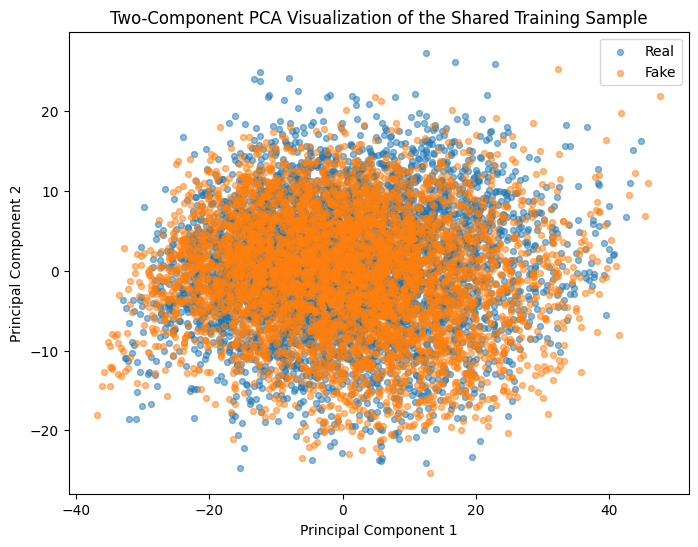

Variance explained by the first two components: 0.334


In [ ]:
pca_2d_transformer = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=SEED,
)
pca_2d_coordinates = pca_2d_transformer.fit_transform(pca_train_pixel_features)

plt.figure(figsize=(8, 6))

for class_value, class_name in [
    (REAL_LABEL, "Real"),
    (FAKE_LABEL, "Fake"),
]:
    class_mask = project_train_targets == class_value
    plt.scatter(
        pca_2d_coordinates[class_mask, 0],
        pca_2d_coordinates[class_mask, 1],
        label=class_name,
        alpha=0.5,
        s=18,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Two-Component PCA Visualization of the Shared Training Sample")
plt.legend()
plt.show()

print(
    "Variance explained by the first two components:",
    f"{pca_2d_transformer.explained_variance_ratio_.sum():.3f}",
)

### What the plot means

Each point represents one image. If the classes formed clearly separated groups, the largest sources of pixel variation would help distinguish real from fake.

If the classes overlap, it does not prove that classification is impossible, but it does mean that two linear components do not preserve enough class-related information.

In this situation, the two largest sources of pixel variation do not clearly separate real from fake images.

The next experiment compares several PCA sizes with logistic regression.

## 11. Train-only PCA classification

Each PCA transformer is fitted only on the shared training features. It then transforms the separate shared validation features.

The experiment function returns its transformer, classifier, predictions, and metrics.

Note: It does not update a global result object.


In [ ]:
pca_experiments = None


def run_pca_logistic_experiment(experiment_name, component_setting):
    """Fit PCA on training data only, then evaluate on shared validation data."""
    use_variance_threshold = isinstance(component_setting, float)

    pca_transformer = PCA(
        n_components=component_setting,
        svd_solver="full" if use_variance_threshold else "randomized",
        random_state=SEED,
    )

    pca_train_features = pca_transformer.fit_transform(pca_train_pixel_features)
    pca_valid_features = pca_transformer.transform(pca_valid_pixel_features)

    pca_logistic_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "logistic_regression",
                LogisticRegression(
                    max_iter=5000,
                    random_state=SEED,
                ),
            ),
        ]
    )

    pca_logistic_model.fit(
        pca_train_features,
        project_train_targets,
    )
    pca_valid_predictions = pca_logistic_model.predict(pca_valid_features)

    pca_metrics = calculate_classification_metrics(
        experiment_name,
        project_valid_targets,
        pca_valid_predictions,
    )

    return {
        "pca_transformer": pca_transformer,
        "classifier": pca_logistic_model,
        "train_features": pca_train_features,
        "valid_features": pca_valid_features,
        "valid_predictions": pca_valid_predictions,
        "metrics": pca_metrics,
        "fitted_component_count": int(pca_transformer.n_components_),
    }


pca_experiments = {
    "PCA + logistic regression (2 components)": run_pca_logistic_experiment(
        "PCA + logistic regression (2 components)",
        component_setting=2,
    ),
    "PCA + logistic regression (50 components)": run_pca_logistic_experiment(
        "PCA + logistic regression (50 components)",
        component_setting=50,
    ),
    "PCA + logistic regression (95% variance)": run_pca_logistic_experiment(
        "PCA + logistic regression (95% variance)",
        component_setting=0.95,
    ),
}

pca_result_rows = []

for experiment_name, experiment_details in pca_experiments.items():
    result_row = experiment_details["metrics"].copy()
    result_row["PCA components"] = experiment_details["fitted_component_count"]
    pca_result_rows.append(result_row)

pca_results_table = pd.DataFrame(pca_result_rows)
display(pca_results_table.round(4))

,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1,PCA components
0,PCA + logistic regression (2 components),Official validation sample,2000,0.5000,0.5000,0.486,0.4929,2
1,PCA + logistic regression (50 components),Official validation sample,2000,0.6485,0.6498,0.644,0.6469,50
2,PCA + logistic regression (95% variance),Official validation sample,2000,0.6860,0.6775,0.710,0.6934,406


## 12. PCA confusion matrices

Accuracy summarizes the percentage of correct predictions, but it does not show which errors are occurring.

Fake precision answers: **Of the images predicted to be fake, how many were actually fake?**

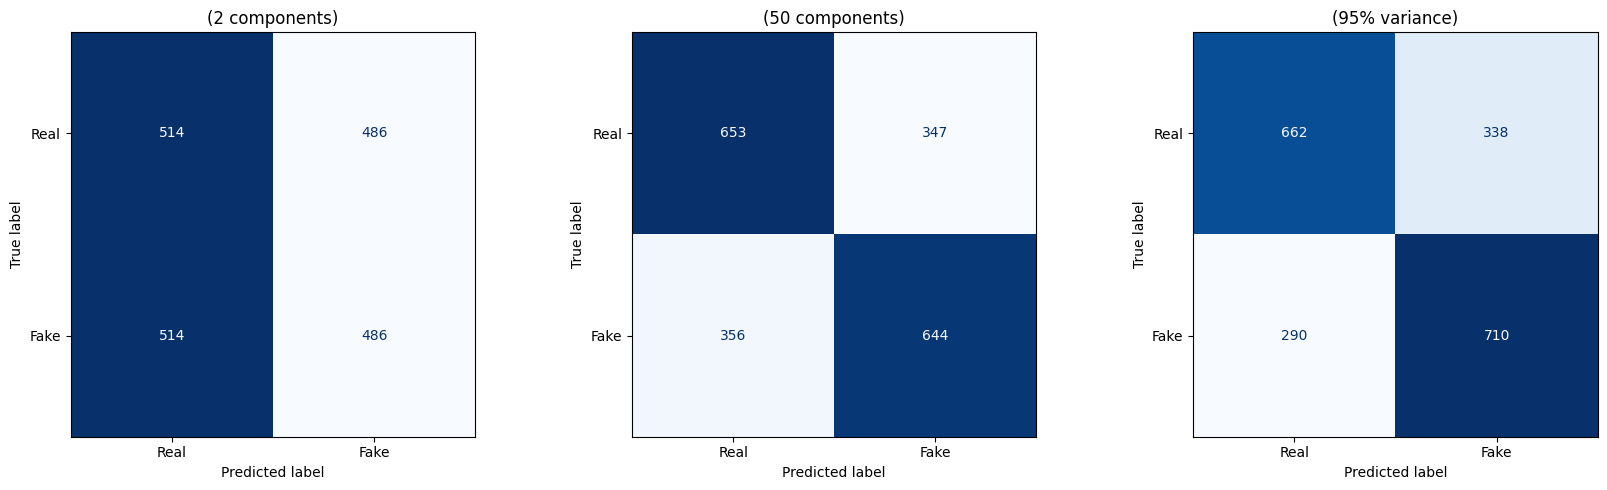

In [ ]:
figure, axes = plt.subplots(1, 3, figsize=(17, 5))

for axis, (experiment_name, experiment_details) in zip(
    axes,
    pca_experiments.items(),
):
    ConfusionMatrixDisplay.from_predictions(
        project_valid_targets,
        experiment_details["valid_predictions"],
        display_labels=CLASS_NAMES,
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(experiment_name.replace("PCA + logistic regression ", ""))

plt.tight_layout()
plt.show()

### PCA reflection

I expect two components to be too restrictive because they preserve only a small fraction of the image information. More components may improve classification, but retaining more pixel variance does not automatically mean retaining more real/fake evidence.

These are still linear features and a linear classifier. The next section changes the representation by moving from pixel space to frequency space.

# Part III: Frequency-Domain Features

## 13. Build shared FFT representations

Images are usually represented by the brightness and color of individual pixels. The Fast Fourier Transform (FFT) provides another representation by measuring how much broad structure, medium-scale pattern, and fine detail appear in an image.

Low frequencies correspond to gradual changes such as lighting and large facial shapes, while high frequencies correspond to edges, hair, texture, and rapid pixel changes. After calculating the FFT, the low-frequency values are moved to the center to make the spectrum easier to view.

Because FFT magnitudes can vary greatly, `log1p` compresses the values so that weaker patterns remain visible. `log1p` is used because log(0) is undefined and FFT magnitudes can be zero. In this experiment, the same training and validation images used by the other models are converted into FFT spectra so that their performance can be compared fairly.


In [ ]:
FFT_IMAGE_SIZE = (64, 64)


def compute_log_fft_spectrum(image_path, image_size=FFT_IMAGE_SIZE):
    """Return a centered log-magnitude FFT spectrum."""
    with Image.open(image_path) as image:
        grayscale_image = image.convert("L").resize(image_size)
        grayscale_array = np.asarray(grayscale_image, dtype=np.float32)

    fft_values = np.fft.fft2(grayscale_array)
    shifted_fft_values = np.fft.fftshift(fft_values)
    log_magnitude_spectrum = np.log1p(np.abs(shifted_fft_values))

    return log_magnitude_spectrum.astype(np.float32)


fft_train_spectra = np.stack(
    [compute_log_fft_spectrum(path) for path in project_train_paths]
)
fft_valid_spectra = np.stack(
    [compute_log_fft_spectrum(path) for path in project_valid_paths]
)

fft_train_flat_features = fft_train_spectra.reshape(
    len(fft_train_spectra),
    -1,
)
fft_valid_flat_features = fft_valid_spectra.reshape(
    len(fft_valid_spectra),
    -1,
)

print(f"FFT training spectrum shape: {fft_train_spectra.shape}")
print(f"FFT validation spectrum shape: {fft_valid_spectra.shape}")
print(f"Flattened FFT training shape: {fft_train_flat_features.shape}")
print(f"Flattened FFT validation shape: {fft_valid_flat_features.shape}")

FFT training spectrum shape: (10000, 64, 64)
FFT validation spectrum shape: (2000, 64, 64)
Flattened FFT training shape: (10000, 4096)
Flattened FFT validation shape: (2000, 4096)


## 14. Visualize average and individual FFT spectra

The average spectra show broad class-level frequency patterns. The individual examples help prevent the averages from hiding variation between images.

The example images come from the already seeded sample, so this section does not introduce new randomness.

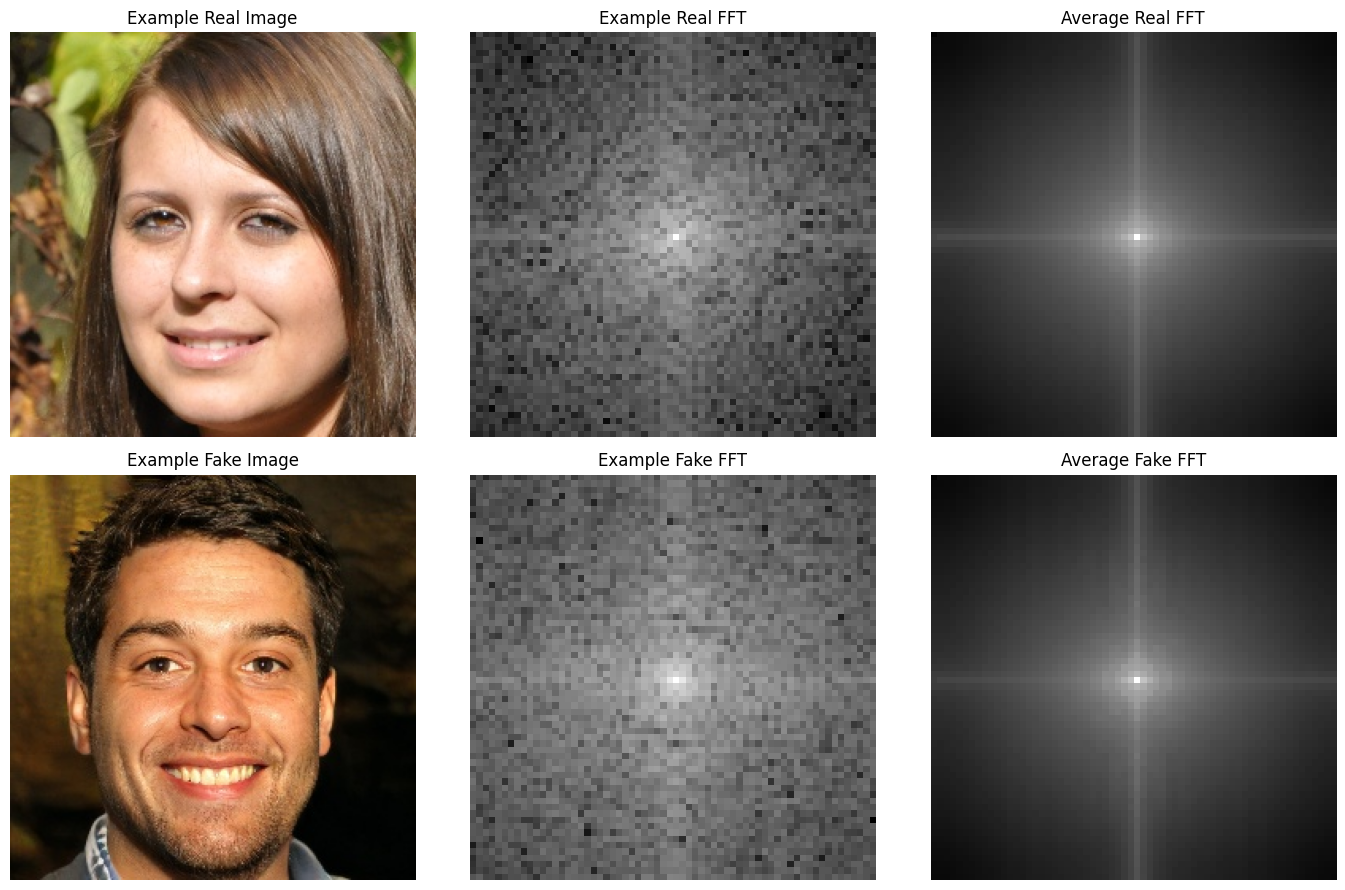

In [ ]:
fft_real_mask = project_train_targets == REAL_LABEL
fft_fake_mask = project_train_targets == FAKE_LABEL

average_real_fft_spectrum = fft_train_spectra[fft_real_mask].mean(axis=0)
average_fake_fft_spectrum = fft_train_spectra[fft_fake_mask].mean(axis=0)

first_real_index = int(np.flatnonzero(fft_real_mask)[0])
first_fake_index = int(np.flatnonzero(fft_fake_mask)[0])

figure, axes = plt.subplots(2, 3, figsize=(14, 9))

with Image.open(project_train_paths[first_real_index]) as image:
    axes[0, 0].imshow(image.convert("RGB"))
axes[0, 0].set_title("Example Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(
    fft_train_spectra[first_real_index],
    cmap="gray",
)
axes[0, 1].set_title("Example Real FFT")
axes[0, 1].axis("off")

axes[0, 2].imshow(average_real_fft_spectrum, cmap="gray")
axes[0, 2].set_title("Average Real FFT")
axes[0, 2].axis("off")

with Image.open(project_train_paths[first_fake_index]) as image:
    axes[1, 0].imshow(image.convert("RGB"))
axes[1, 0].set_title("Example Fake Image")
axes[1, 0].axis("off")

axes[1, 1].imshow(
    fft_train_spectra[first_fake_index],
    cmap="gray",
)
axes[1, 1].set_title("Example Fake FFT")
axes[1, 1].axis("off")

axes[1, 2].imshow(average_fake_fft_spectrum, cmap="gray")
axes[1, 2].set_title("Average Fake FFT")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Results:

The bright center is expected because natural images usually contain substantial low-frequency energy. Lines or repeated patterns may reflect image structure, alignment, resizing, or generator artifacts.

Visual differences in average spectra are only a hypothesis. The next step tests whether classifiers can use the FFT values on held-out images.

## 15. Logistic regression and Random Forest on FFT features

Both baseline models are trained on the shared official training sample and evaluated on the shared official validation sample.

Logistic regression is combined with feature standardization because FFT values can have different scales. Random Forest does not require standardized inputs.

The models and result variables have separate names, and the metric function returns a new dictionary rather than modifying global state.


In [ ]:
fft_logistic_metrics = None
fft_random_forest_metrics = None

fft_logistic_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=5000,
                random_state=SEED,
            ),
        ),
    ]
)

fft_logistic_model.fit(
    fft_train_flat_features,
    project_train_targets,
)
fft_logistic_valid_predictions = fft_logistic_model.predict(fft_valid_flat_features)

fft_logistic_metrics = calculate_classification_metrics(
    "FFT + logistic regression",
    project_valid_targets,
    fft_logistic_valid_predictions,
)


fft_random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)

fft_random_forest_model.fit(
    fft_train_flat_features,
    project_train_targets,
)
fft_random_forest_valid_predictions = fft_random_forest_model.predict(
    fft_valid_flat_features
)

fft_random_forest_metrics = calculate_classification_metrics(
    "FFT + Random Forest",
    project_valid_targets,
    fft_random_forest_valid_predictions,
)


fft_baseline_results_table = pd.DataFrame(
    [fft_logistic_metrics, fft_random_forest_metrics]
)
display(fft_baseline_results_table.round(4))

,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1
0,FFT + logistic regression,Official validation sample,2000,0.6120,0.6111,0.616,0.6135
1,FFT + Random Forest,Official validation sample,2000,0.6055,0.6174,0.555,0.5845


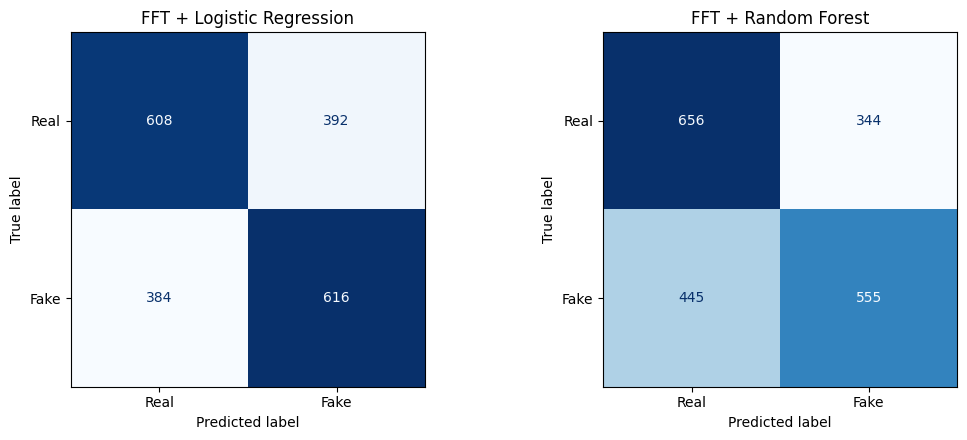

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    project_valid_targets,
    fft_logistic_valid_predictions,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("FFT + Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    project_valid_targets,
    fft_random_forest_valid_predictions,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("FFT + Random Forest")

plt.tight_layout()
plt.show()

### FFT baseline reflection

These models test whether fixed, hand-created frequency features contain useful signal. If performance is only slightly above chance, the representation may still contain information that a nonlinear model can use.

A CNN can preserve the two-dimensional arrangement of the FFT spectrum instead of flattening it into unrelated columns.

# Part IV: Neural-Network Experiments

## 16. Prepare FFT data for a small CNN

The same shared FFT training and validation representations are reshaped to `1 × 64 × 64`.

The normalization values are calculated from the training data only and then applied to both training and validation data. This avoids using validation statistics during training.

This cell creates datasets, but it does not create DataLoaders. The experiment cell creates fresh seeded DataLoaders immediately before training.


In [ ]:
fft_cnn_train_mean = float(fft_train_flat_features.mean())
fft_cnn_train_standard_deviation = float(fft_train_flat_features.std())

if fft_cnn_train_standard_deviation == 0:
    raise ValueError("FFT training features have zero standard deviation.")

fft_cnn_train_normalized = (
    fft_train_flat_features - fft_cnn_train_mean
) / fft_cnn_train_standard_deviation

fft_cnn_valid_normalized = (
    fft_valid_flat_features - fft_cnn_train_mean
) / fft_cnn_train_standard_deviation


fft_cnn_train_tensor = torch.tensor(
    fft_cnn_train_normalized.reshape(-1, 1, 64, 64),
    dtype=torch.float32,
)
fft_cnn_valid_tensor = torch.tensor(
    fft_cnn_valid_normalized.reshape(-1, 1, 64, 64),
    dtype=torch.float32,
)

fft_cnn_train_target_tensor = torch.tensor(
    project_train_targets,
    dtype=torch.float32,
)
fft_cnn_valid_target_tensor = torch.tensor(
    project_valid_targets,
    dtype=torch.float32,
)


fft_cnn_train_dataset = TensorDataset(
    fft_cnn_train_tensor,
    fft_cnn_train_target_tensor,
)
fft_cnn_valid_dataset = TensorDataset(
    fft_cnn_valid_tensor,
    fft_cnn_valid_target_tensor,
)

print(f"FFT CNN training observations: {len(fft_cnn_train_dataset)}")
print(f"FFT CNN validation observations: {len(fft_cnn_valid_dataset)}")

FFT CNN training observations: 10000
FFT CNN validation observations: 2000


## 17. Shared PyTorch training and evaluation helpers

These functions keep the training logic consistent across the FFT CNN and raw-image CNN.

The variables inside the functions are local, so names like `model_outputs` or `batch_targets` disappear when the function ends. The trained models, optimizers, loaders, and histories still receive experiment-specific global names.

The evaluation function converts probabilities above 0.50 to **Fake = 1**.

In [ ]:
def train_binary_torch_model(
    neural_network,
    training_loader,
    loss_function,
    optimizer_object,
    epoch_count,
    device,
):
    """Train a one-logit binary classifier and return average epoch losses."""
    epoch_loss_history = []

    for epoch_index in range(epoch_count):
        neural_network.train()
        running_loss = 0.0

        for batch_images, batch_targets in training_loader:
            batch_images = batch_images.to(device)
            batch_targets = batch_targets.to(device).float().view(-1, 1)

            optimizer_object.zero_grad()

            model_logits = neural_network(batch_images)
            batch_loss = loss_function(model_logits, batch_targets)

            batch_loss.backward()
            optimizer_object.step()

            running_loss += batch_loss.item()

        average_epoch_loss = running_loss / len(training_loader)
        epoch_loss_history.append(average_epoch_loss)

        print(
            f"Epoch {epoch_index + 1:02d}/{epoch_count} "
            f"- average loss: {average_epoch_loss:.4f}"
        )

    return epoch_loss_history


def evaluate_binary_torch_model(
    experiment_name,
    neural_network,
    evaluation_loader,
    device,
):
    """Evaluate a one-logit model using Fake = 1 as the positive class."""
    neural_network.eval()

    collected_targets = []
    collected_predictions = []
    collected_probabilities = []

    with torch.no_grad():
        for batch_images, batch_targets in evaluation_loader:
            batch_images = batch_images.to(device)

            model_logits = neural_network(batch_images)
            fake_probabilities = torch.sigmoid(model_logits).view(-1)
            batch_predictions = (fake_probabilities >= 0.50).to(torch.int64)

            collected_targets.extend(batch_targets.view(-1).cpu().numpy().astype(int))
            collected_predictions.extend(batch_predictions.cpu().numpy().astype(int))
            collected_probabilities.extend(fake_probabilities.cpu().numpy())

    true_targets = np.array(collected_targets)
    predicted_targets = np.array(collected_predictions)
    fake_probabilities = np.array(collected_probabilities)

    result_metrics = calculate_classification_metrics(
        experiment_name,
        true_targets,
        predicted_targets,
    )

    return {
        "true_targets": true_targets,
        "predicted_targets": predicted_targets,
        "fake_probabilities": fake_probabilities,
        "metrics": result_metrics,
    }

## 18. Train a CNN on FFT spectra

This CNN uses two convolutional blocks. The first block learns simple local frequency patterns, and the second can combine them into more complex patterns.

`BCEWithLogitsLoss` is used because the model returns one raw logit. This function combines the sigmoid transformation and binary cross-entropy calculation in a numerically stable way.

FFT CNN training batches: 313
FFT CNN validation batches: 63
Epoch 01/10 - average loss: 0.6884
Epoch 02/10 - average loss: 0.6780
Epoch 03/10 - average loss: 0.6735
Epoch 04/10 - average loss: 0.6657
Epoch 05/10 - average loss: 0.6598
Epoch 06/10 - average loss: 0.6529
Epoch 07/10 - average loss: 0.6460
Epoch 08/10 - average loss: 0.6406
Epoch 09/10 - average loss: 0.6351
Epoch 10/10 - average loss: 0.6322


,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1
0,FFT CNN,Official validation sample,2000,0.5955,0.5748,0.734,0.6447


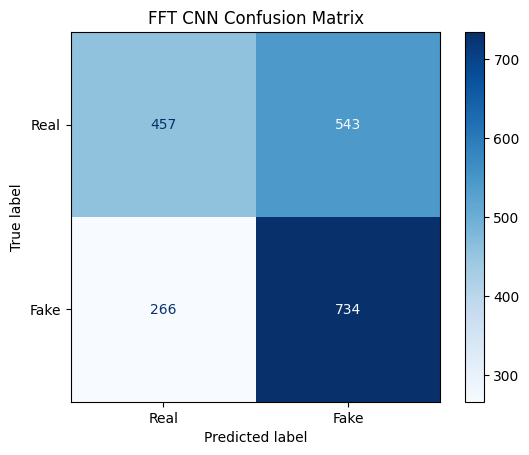

In [ ]:
# Clear any result left over from an earlier run of this experiment. After the model is evaluated successfully, this variable will contain a dictionary of metrics such as accuracy, precision, recall, and F1.

fft_cnn_metrics = None

# Define a custom Convolutional Neural Network for FFT spectra. The model inherits from nn.Module, which is the base class used for neural-network models in PyTorch.


class SmallFFTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # The feature extractor learns useful visual patterns from the two-dimensional FFT spectra.
        # nn.Sequential runs each layer in the order listed.

        self.feature_extractor = nn.Sequential(

            # ---------------------------------------------------------
            # ***** First convolutional block
            # ---------------------------------------------------------
            # Apply 16 different 3 × 3 convolution filters to the input.
            #
            # Input channels: 1
            # The FFT spectrum is a single-channel grayscale array.
            #
            # Output channels: 16
            # The layer learns 16 different feature maps.
            #
            # kernel_size=3:
            # Each filter examines a local 3 × 3 region.
            #
            # padding=1:
            # Adds a one-pixel border so the width and height remain
            # 64 × 64 after the convolution.
            #
            # Shape change:
            #     1 × 64 × 64
            #          ↓
            #     16 × 64 × 64

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1,
            ),

            # ---------------------------------------------------------
            # Normalize the 16 feature channels within each batch.
            #
            # This helps keep the activations on a more stable scale
            # during training and may make optimization more stable.
            #
            # The tensor shape does not change:
            #
            #     16 × 64 × 64

            nn.BatchNorm2d(16),

            # ---------------------------------------------------------
            # Apply the ReLU activation function.
            #
            # ReLU changes negative values to zero and keeps positive
            # values:
            #
            #     ReLU(x) = max(0, x)
            #
            # This introduces nonlinearity, which allows the network
            # to learn more complex relationships than a purely linear
            # sequence of operations could learn.

            nn.ReLU(),

            # ---------------------------------------------------------
            # Reduce each feature map by taking the maximum value from
            # every 2 × 2 region.
            #
            # This reduces the height and width by half:
            #
            #     16 × 64 × 64
            #          ↓
            #     16 × 32 × 32
            #
            # Pooling reduces computation and keeps the strongest local
            # feature responses.

            nn.MaxPool2d(kernel_size=2),

            # ---------------------------------------------------------
            # Second convolutional block
            # ---------------------------------------------------------
            # Apply 32 new 3 × 3 filters to the 16 feature maps produced
            # by the first block.
            #
            # The first block may learn simpler patterns, such as short
            # lines or local brightness changes.
            #
            # The second block can combine those simpler patterns into
            # more complex frequency arrangements.
            #
            # Shape change:
            #
            #     16 × 32 × 32
            #           ↓
            #     32 × 32 × 32

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1,
            ),

            # ---------------------------------------------------------
            # Normalize the 32 feature channels.
            #
            # The shape remains:
            #
            #     32 × 32 × 32

            nn.BatchNorm2d(32),

            # ---------------------------------------------------------
            # Apply another nonlinear ReLU activation.

            nn.ReLU(),

            # ---------------------------------------------------------
            # Reduce the height and width by half again.
            #
            # Shape change:
            #
            #     32 × 32 × 32
            #           ↓
            #     32 × 16 × 16

            nn.MaxPool2d(kernel_size=2),
        )

        # The classifier uses the features learned by the convolutional
        # blocks to make the final Real-or-Fake prediction.

        self.classifier = nn.Sequential(

            # Convert the 3D feature maps into one long feature vector.
            nn.Flatten(),

            # Combine the 8,192 extracted feature values into 64 learned
            # classifier features. Each of the 64 outputs is a weighted combination of all 8,192 input features.
            nn.Linear(
                in_features=32 * 16 * 16,
                out_features=64,
            ),

            # Add nonlinearity after the first fully connected layer.
            nn.ReLU(),

            # Randomly set 30% of the 64 classifier features to zero during training. Discourages the model from relying too heavily on a small number of features and may help reduce overfitting. Dropout is active during model.train() and automatically disabled during model.eval().
            nn.Dropout(p=0.30),

            # Produce one final raw score for each image (logit).
            #     negative logit → stronger evidence for Real
            #     positive logit → stronger evidence for Fake
            # BCEWithLogitsLoss will use this raw logit during training.
            nn.Linear(
                in_features=64,
                out_features=1,
            ),
        )

    # Defines how input data moves through the network.
    def forward(self, input_tensor):

        # Pass the FFT spectra through the convolutional feature extractor.
        # Input batch shape: batch_size × 1 × 64 × 64
        # Output shape: batch_size × 32 × 16 × 16

        extracted_features = self.feature_extractor(input_tensor)

        # Pass the extracted feature maps through the classifier.
        # Final output shape: batch_size × 1
        # Each image receives one raw logit.
        return self.classifier(extracted_features)



# Create fresh DataLoaders

# Recreate the training DataLoader every time this experiment cell runs. This also creates a new seeded random generator, so the training shuffle starts from the same seed rather than continuing from the state of a previously used DataLoader.
fft_cnn_train_loader = create_seeded_data_loader(

    # Dataset containing the normalized FFT training tensors and labels.
    fft_cnn_train_dataset,

    # Shuffle the training examples. Prevents the model from always seeing images in the same fixed order.
    shuffle=True,

    # Use the notebook-wide seed, so the shuffle can be reproduced during a clean rerun.
    seed=SEED,
)


# Create the validation DataLoader.
fft_cnn_valid_loader = create_seeded_data_loader(

    # Dataset containing the normalized FFT validation tensors and labels.
    fft_cnn_valid_dataset,

    # Validation data does not need to be shuffled because the model is not learning from it.
    shuffle=False,
)


# Print the number of batches in each DataLoader.
print(f"FFT CNN training batches: " f"{len(fft_cnn_train_loader)}")
print(f"FFT CNN validation batches: " f"{len(fft_cnn_valid_loader)}")


# Reset the main random-number generators before creating the model.
seed_everything()

# Create an instance of SmallFFTCNN and move it to DEVICE.
fft_cnn_model = SmallFFTCNN().to(DEVICE)


# Define the binary-classification loss function.
#
# BCEWithLogitsLoss expects:
#
#     model output = one raw logit
#     target label = 0 or 1
#
# In this notebook:
#
#     Real = 0
#     Fake = 1
#
# It combines:
#
#     sigmoid transformation
#             +
#     binary cross-entropy loss
#
# in one numerically stable operation.
fft_cnn_loss_function = nn.BCEWithLogitsLoss()


# Creates the Adam optimizer, changes the model's trainable weights based on the gradients calculated during backpropagation.
fft_cnn_optimizer = torch.optim.Adam(

    # Provides Adam all trainable model parameters, including convolutional filters, linear weights, biases, and batch-normalization parameters.
    fft_cnn_model.parameters(),

    # Set the learning rate, controls the approximate size of each weight update.
    lr=0.00001,
)


# Train the model

# Call the shared binary-training helper function. Loops through the training batches, calculates loss, performs backpropagation, updates the weights, and records the average loss for each epoch.
fft_cnn_loss_history = train_binary_torch_model(

    # The CNN that will be trained.
    neural_network=fft_cnn_model,

    # The seeded and shuffled FFT training batches.
    training_loader=fft_cnn_train_loader,

    # The binary classification loss function.
    loss_function=fft_cnn_loss_function,

    # The Adam optimizer that updates the model's parameters.
    optimizer_object=fft_cnn_optimizer,

    # One epoch means one complete pass through the training dataset.
    epoch_count=10,

    # Train using the selected CPU or GPU device.
    device=DEVICE,
)

# Evaluate the trained CNN on the validation dataset. Switches the model into evaluation mode; disables gradient calculation; produces raw logits; converts logits to fake probabilities using sigmoid; converts probabilities to Real-or-Fake predictions; compares predictions with the correct labels; calculates classification metrics.
fft_cnn_evaluation = evaluate_binary_torch_model(

    # Name displayed in the final results table.
    experiment_name="FFT CNN",

    # The trained neural network.
    neural_network=fft_cnn_model,

    # The validation batches that were not used to update the model.
    evaluation_loader=fft_cnn_valid_loader,

    # Evaluate on the same device used for training.
    device=DEVICE,
)


# Extract and display the metrics

# Returns a dictionary containing true_targets, predicted_targets, fake_probabilities, metrics
fft_cnn_metrics = fft_cnn_evaluation["metrics"]


# Converts the metrics dictionary into a one-row pandas DataFrame.
display(pd.DataFrame([fft_cnn_metrics]).round(4))


# Create a confusion matrix by comparing the actual validation labels with the model's predicted labels.
ConfusionMatrixDisplay.from_predictions(

    # Correct validation labels.
    fft_cnn_evaluation["true_targets"],

    # Labels predicted by the FFT CNN.
    fft_cnn_evaluation["predicted_targets"],

    # Use readable class names instead of displaying only 0 and 1.
    display_labels=CLASS_NAMES,

    # Use a blue color scale for the matrix.
    cmap="Blues",
)

# Add a title to the confusion-matrix plot.
plt.title("FFT CNN Confusion Matrix")

# Render and display the completed plot.
plt.show()

FFT CNN training batches: 313
FFT CNN validation batches: 63
Epoch 01/10 - average loss: 0.6884
Epoch 02/10 - average loss: 0.6780
Epoch 03/10 - average loss: 0.6735
Epoch 04/10 - average loss: 0.6657
Epoch 05/10 - average loss: 0.6598
Epoch 06/10 - average loss: 0.6529
Epoch 07/10 - average loss: 0.6460
Epoch 08/10 - average loss: 0.6406
Epoch 09/10 - average loss: 0.6351
Epoch 10/10 - average loss: 0.6322


,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1
0,FFT CNN,Official validation sample,2000,0.5955,0.5748,0.734,0.6447


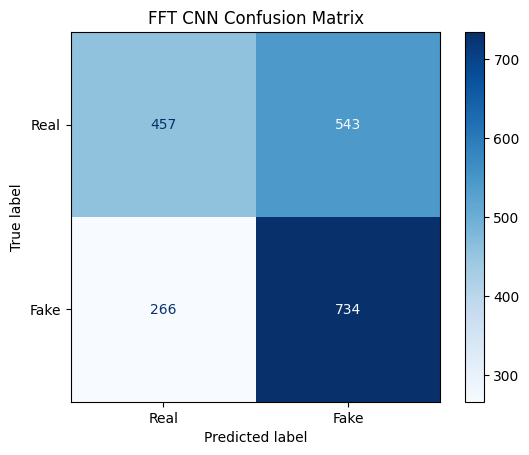

In [ ]:
# Clear any result left over from an earlier run of this experiment. After the model is evaluated successfully, this variable will contain a dictionary of metrics such as accuracy, precision, recall, and F1.

fft_cnn_metrics = None

# Define a custom Convolutional Neural Network for FFT spectra. The model inherits from nn.Module, which is the base class used for neural-network models in PyTorch.


class SmallFFTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # The feature extractor learns useful visual patterns from the two-dimensional FFT spectra.
        # nn.Sequential runs each layer in the order listed.

        self.feature_extractor = nn.Sequential(

            # ---------------------------------------------------------
            # ***** First convolutional block
            # ---------------------------------------------------------
            # Apply 16 different 3 × 3 convolution filters to the input.
            #
            # Input channels: 1
            # The FFT spectrum is a single-channel grayscale array.
            #
            # Output channels: 16
            # The layer learns 16 different feature maps.
            #
            # kernel_size=3:
            # Each filter examines a local 3 × 3 region.
            #
            # padding=1:
            # Adds a one-pixel border so the width and height remain
            # 64 × 64 after the convolution.
            #
            # Shape change:
            #     1 × 64 × 64
            #          ↓
            #     16 × 64 × 64

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1,
            ),

            # ---------------------------------------------------------
            # Normalize the 16 feature channels within each batch.
            #
            # This helps keep the activations on a more stable scale
            # during training and may make optimization more stable.
            #
            # The tensor shape does not change:
            #
            #     16 × 64 × 64

            nn.BatchNorm2d(16),

            # ---------------------------------------------------------
            # Apply the ReLU activation function.
            #
            # ReLU changes negative values to zero and keeps positive
            # values:
            #
            #     ReLU(x) = max(0, x)
            #
            # This introduces nonlinearity, which allows the network
            # to learn more complex relationships than a purely linear
            # sequence of operations could learn.

            nn.ReLU(),

            # ---------------------------------------------------------
            # Reduce each feature map by taking the maximum value from
            # every 2 × 2 region.
            #
            # This reduces the height and width by half:
            #
            #     16 × 64 × 64
            #          ↓
            #     16 × 32 × 32
            #
            # Pooling reduces computation and keeps the strongest local
            # feature responses.

            nn.MaxPool2d(kernel_size=2),

            # ---------------------------------------------------------
            # Second convolutional block
            # ---------------------------------------------------------
            # Apply 32 new 3 × 3 filters to the 16 feature maps produced
            # by the first block.
            #
            # The first block may learn simpler patterns, such as short
            # lines or local brightness changes.
            #
            # The second block can combine those simpler patterns into
            # more complex frequency arrangements.
            #
            # Shape change:
            #
            #     16 × 32 × 32
            #           ↓
            #     32 × 32 × 32

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1,
            ),

            # ---------------------------------------------------------
            # Normalize the 32 feature channels.
            #
            # The shape remains:
            #
            #     32 × 32 × 32

            nn.BatchNorm2d(32),

            # ---------------------------------------------------------
            # Apply another nonlinear ReLU activation.

            nn.ReLU(),

            # ---------------------------------------------------------
            # Reduce the height and width by half again.
            #
            # Shape change:
            #
            #     32 × 32 × 32
            #           ↓
            #     32 × 16 × 16

            nn.MaxPool2d(kernel_size=2),
        )

        # The classifier uses the features learned by the convolutional
        # blocks to make the final Real-or-Fake prediction.

        self.classifier = nn.Sequential(

            # Convert the 3D feature maps into one long feature vector.
            nn.Flatten(),

            # Combine the 8,192 extracted feature values into 64 learned
            # classifier features. Each of the 64 outputs is a weighted combination of all 8,192 input features.
            nn.Linear(
                in_features=32 * 16 * 16,
                out_features=64,
            ),

            # Add nonlinearity after the first fully connected layer.
            nn.ReLU(),

            # Randomly set 30% of the 64 classifier features to zero during training. Discourages the model from relying too heavily on a small number of features and may help reduce overfitting. Dropout is active during model.train() and automatically disabled during model.eval().
            nn.Dropout(p=0.30),

            # Produce one final raw score for each image (logit).
            #     negative logit → stronger evidence for Real
            #     positive logit → stronger evidence for Fake
            # BCEWithLogitsLoss will use this raw logit during training.
            nn.Linear(
                in_features=64,
                out_features=1,
            ),
        )

    # Defines how input data moves through the network.
    def forward(self, input_tensor):

        # Pass the FFT spectra through the convolutional feature extractor.
        # Input batch shape: batch_size × 1 × 64 × 64
        # Output shape: batch_size × 32 × 16 × 16

        extracted_features = self.feature_extractor(input_tensor)

        # Pass the extracted feature maps through the classifier.
        # Final output shape: batch_size × 1
        # Each image receives one raw logit.
        return self.classifier(extracted_features)



# Create fresh DataLoaders

# Recreate the training DataLoader every time this experiment cell runs. This also creates a new seeded random generator, so the training shuffle starts from the same seed rather than continuing from the state of a previously used DataLoader.
fft_cnn_train_loader = create_seeded_data_loader(

    # Dataset containing the normalized FFT training tensors and labels.
    fft_cnn_train_dataset,

    # Shuffle the training examples. Prevents the model from always seeing images in the same fixed order.
    shuffle=True,

    # Use the notebook-wide seed, so the shuffle can be reproduced during a clean rerun.
    seed=SEED,
)


# Create the validation DataLoader.
fft_cnn_valid_loader = create_seeded_data_loader(

    # Dataset containing the normalized FFT validation tensors and labels.
    fft_cnn_valid_dataset,

    # Validation data does not need to be shuffled because the model is not learning from it.
    shuffle=False,
)


# Print the number of batches in each DataLoader.
print(f"FFT CNN training batches: " f"{len(fft_cnn_train_loader)}")
print(f"FFT CNN validation batches: " f"{len(fft_cnn_valid_loader)}")


# Reset the main random-number generators before creating the model.
seed_everything()

# Create an instance of SmallFFTCNN and move it to DEVICE.
fft_cnn_model = SmallFFTCNN().to(DEVICE)


# Define the binary-classification loss function.
#
# BCEWithLogitsLoss expects:
#
#     model output = one raw logit
#     target label = 0 or 1
#
# In this notebook:
#
#     Real = 0
#     Fake = 1
#
# It combines:
#
#     sigmoid transformation
#             +
#     binary cross-entropy loss
#
# in one numerically stable operation.
fft_cnn_loss_function = nn.BCEWithLogitsLoss()


# Creates the Adam optimizer, changes the model's trainable weights based on the gradients calculated during backpropagation.
fft_cnn_optimizer = torch.optim.Adam(

    # Provides Adam all trainable model parameters, including convolutional filters, linear weights, biases, and batch-normalization parameters.
    fft_cnn_model.parameters(),

    # Set the learning rate, controls the approximate size of each weight update.
    lr=0.00001,
)


# Train the model

# Call the shared binary-training helper function. Loops through the training batches, calculates loss, performs backpropagation, updates the weights, and records the average loss for each epoch.
fft_cnn_loss_history = train_binary_torch_model(

    # The CNN that will be trained.
    neural_network=fft_cnn_model,

    # The seeded and shuffled FFT training batches.
    training_loader=fft_cnn_train_loader,

    # The binary classification loss function.
    loss_function=fft_cnn_loss_function,

    # The Adam optimizer that updates the model's parameters.
    optimizer_object=fft_cnn_optimizer,

    # One epoch means one complete pass through the training dataset.
    epoch_count=10,

    # Train using the selected CPU or GPU device.
    device=DEVICE,
)

# Evaluate the trained CNN on the validation dataset. Switches the model into evaluation mode; disables gradient calculation; produces raw logits; converts logits to fake probabilities using sigmoid; converts probabilities to Real-or-Fake predictions; compares predictions with the correct labels; calculates classification metrics.
fft_cnn_evaluation = evaluate_binary_torch_model(

    # Name displayed in the final results table.
    experiment_name="FFT CNN",

    # The trained neural network.
    neural_network=fft_cnn_model,

    # The validation batches that were not used to update the model.
    evaluation_loader=fft_cnn_valid_loader,

    # Evaluate on the same device used for training.
    device=DEVICE,
)


# Extract and display the metrics

# Returns a dictionary containing true_targets, predicted_targets, fake_probabilities, metrics
fft_cnn_metrics = fft_cnn_evaluation["metrics"]


# Converts the metrics dictionary into a one-row pandas DataFrame.
display(pd.DataFrame([fft_cnn_metrics]).round(4))


# Create a confusion matrix by comparing the actual validation labels with the model's predicted labels.
ConfusionMatrixDisplay.from_predictions(

    # Correct validation labels.
    fft_cnn_evaluation["true_targets"],

    # Labels predicted by the FFT CNN.
    fft_cnn_evaluation["predicted_targets"],

    # Use readable class names instead of displaying only 0 and 1.
    display_labels=CLASS_NAMES,

    # Use a blue color scale for the matrix.
    cmap="Blues",
)

# Add a title to the confusion-matrix plot.
plt.title("FFT CNN Confusion Matrix")

# Render and display the completed plot.
plt.show()

### FFT CNN reflection

The loss should generally decrease if the model is learning the training data. Validation metrics are more important than training loss because they show how well the learned pattern transfers to held-out observations.

A large gap between training improvement and test performance would suggest overfitting. The next experiment returns to raw RGB images so the CNN can learn color and spatial features directly.

## 19. Raw RGB datasets from the shared paths

This section creates `64 × 64` RGB datasets from the same shared image paths used in the PCA and FFT experiments.

It does not create another sample or split. It also does not create the DataLoaders yet. The training cell recreates them immediately before each run.

In [ ]:
RAW_RGB_IMAGE_SIZE = (64, 64)


class FacePathDataset(Dataset):
    """Load an image from its path and return a numeric target."""

    def __init__(self, image_paths, numeric_targets, image_transform):
        if len(image_paths) != len(numeric_targets):
            raise ValueError("Image paths and targets must have equal length.")

        self.image_paths = list(image_paths)
        self.numeric_targets = np.asarray(numeric_targets, dtype=np.int64)
        self.image_transform = image_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with Image.open(self.image_paths[index]) as image:
            rgb_image = image.convert("RGB")

        transformed_image = self.image_transform(rgb_image)
        numeric_target = torch.tensor(
            self.numeric_targets[index],
            dtype=torch.float32,
        )

        return transformed_image, numeric_target


raw_rgb_transform = transforms.Compose(
    [
        transforms.Resize(RAW_RGB_IMAGE_SIZE),
        transforms.ToTensor(),
    ]
)

raw_rgb_train_dataset = FacePathDataset(
    project_train_paths,
    project_train_targets,
    raw_rgb_transform,
)

raw_rgb_valid_dataset = FacePathDataset(
    project_valid_paths,
    project_valid_targets,
    raw_rgb_transform,
)

print(f"Raw RGB training images: {len(raw_rgb_train_dataset)}")
print(f"Raw RGB validation images: {len(raw_rgb_valid_dataset)}")

Raw RGB training images: 10000
Raw RGB validation images: 2000


## 20. Train a small CNN on raw RGB images

This model uses two convolutional blocks followed by adaptive pooling and a small fully connected classifier.

Adaptive pooling reduces the feature map to a fixed size before the linear layer. This makes the architecture easier to understand and avoids a very large fully connected layer.

The model is recreated after resetting the seed, so its initial weights are reproducible.

Raw RGB training batches: 313
Raw RGB validation batches: 63


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01/5 - average loss: 0.6933
Epoch 02/5 - average loss: 0.6921
Epoch 03/5 - average loss: 0.6905
Epoch 04/5 - average loss: 0.6875
Epoch 05/5 - average loss: 0.6834


,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1
0,Raw RGB CNN,Official validation sample,2000,0.5825,0.5724,0.652,0.6096


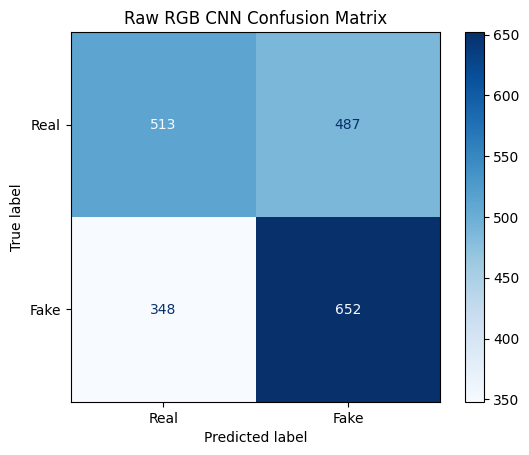

In [ ]:
raw_rgb_cnn_metrics = None


class SmallRawRGBCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 1),
        )

    def forward(self, input_tensor):
        extracted_features = self.feature_extractor(input_tensor)
        return self.classifier(extracted_features)


# Recreate both loaders each time this experiment cell is run.
raw_rgb_train_loader = create_seeded_data_loader(
    raw_rgb_train_dataset,
    shuffle=True,
    seed=SEED,
)
raw_rgb_valid_loader = create_seeded_data_loader(
    raw_rgb_valid_dataset,
    shuffle=False,
)

print(f"Raw RGB training batches: {len(raw_rgb_train_loader)}")
print(f"Raw RGB validation batches: {len(raw_rgb_valid_loader)}")


seed_everything()

raw_rgb_cnn_model = SmallRawRGBCNN().to(DEVICE)
raw_rgb_cnn_loss_function = nn.BCEWithLogitsLoss()
raw_rgb_cnn_optimizer = torch.optim.Adam(
    raw_rgb_cnn_model.parameters(),
    lr=0.00005,
)

raw_rgb_cnn_loss_history = train_binary_torch_model(
    neural_network=raw_rgb_cnn_model,
    training_loader=raw_rgb_train_loader,
    loss_function=raw_rgb_cnn_loss_function,
    optimizer_object=raw_rgb_cnn_optimizer,
    epoch_count=5,
    device=DEVICE,
)

raw_rgb_cnn_evaluation = evaluate_binary_torch_model(
    experiment_name="Raw RGB CNN",
    neural_network=raw_rgb_cnn_model,
    evaluation_loader=raw_rgb_valid_loader,
    device=DEVICE,
)

raw_rgb_cnn_metrics = raw_rgb_cnn_evaluation["metrics"]

display(pd.DataFrame([raw_rgb_cnn_metrics]).round(4))

ConfusionMatrixDisplay.from_predictions(
    raw_rgb_cnn_evaluation["true_targets"],
    raw_rgb_cnn_evaluation["predicted_targets"],
    display_labels=CLASS_NAMES,
    cmap="Blues",
)
plt.title("Raw RGB CNN Confusion Matrix")
plt.show()

### Raw CNN reflection

This experiment tests whether a small network can learn useful features directly from RGB pixels. Because the dataset is limited to one real-image source and one generator family, strong validation performance would still not prove that the model can detect every kind of deepfake.

A pretrained network provides a stronger image representation without requiring this project to learn every low-level visual feature from scratch.

## 21. Transfer learning with ResNet-50

ResNet-50 was pretrained on ImageNet. Its convolutional backbone already recognizes many general visual patterns such as edges, textures, shapes, and object parts.

For this experiment:

1. the same shared training and validation paths are used;
2. the pretrained backbone is frozen;
3. the original classification layer is replaced with a binary head;
4. only the new head is trained;
5. fresh seeded DataLoaders are created whenever the cell is rerun.

ResNet expects larger normalized images, so it uses its own image transform while keeping the underlying observations identical to the other models.


ResNet-50 training batches: 313
ResNet-50 validation batches: 63
Epoch 01/10 - average loss: 0.4411
Epoch 02/10 - average loss: 0.3014
Epoch 03/10 - average loss: 0.2555
Epoch 04/10 - average loss: 0.2222
Epoch 05/10 - average loss: 0.2004
Epoch 06/10 - average loss: 0.1850
Epoch 07/10 - average loss: 0.1696
Epoch 08/10 - average loss: 0.1560
Epoch 09/10 - average loss: 0.1345
Epoch 10/10 - average loss: 0.1253


,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1
0,ResNet-50 transfer learning,Official validation sample,2000,0.8905,0.8483,0.951,0.8967


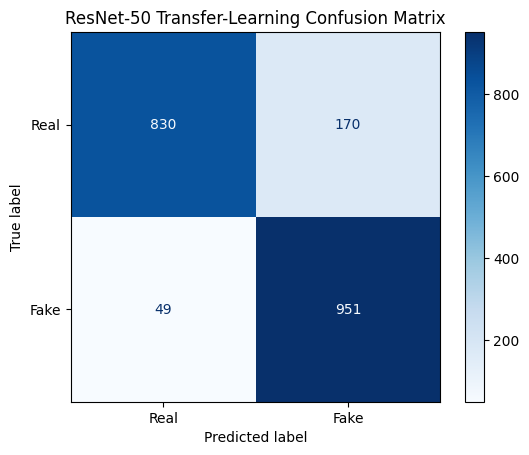

In [ ]:
import torchvision.transforms as transforms
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class FacePathDataset(Dataset):
    """Load an image from its path and return a numeric target."""

    def __init__(self, image_paths, numeric_targets, image_transform):
        if len(image_paths) != len(numeric_targets):
            raise ValueError("Image paths and targets must have equal length.")

        self.image_paths = list(image_paths)
        self.numeric_targets = np.asarray(numeric_targets, dtype=np.int64)
        self.image_transform = image_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with Image.open(self.image_paths[index]) as image:
            rgb_image = image.convert("RGB")

        transformed_image = self.image_transform(rgb_image)
        numeric_target = torch.tensor(
            self.numeric_targets[index],
            dtype=torch.float32,
        )

        return transformed_image, numeric_target

resnet50_metrics = None

RESNET_IMAGE_SIZE = (224, 224)

resnet50_transform = transforms.Compose(
    [
        transforms.Resize(RESNET_IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

resnet50_train_dataset = FacePathDataset(
    project_train_paths,
    project_train_targets,
    resnet50_transform,
)

resnet50_valid_dataset = FacePathDataset(
    project_valid_paths,
    project_valid_targets,
    resnet50_transform,
)

# Recreate both loaders each time this experiment cell is run.
resnet50_train_loader = create_seeded_data_loader(
    resnet50_train_dataset,
    shuffle=True,
    seed=SEED,
)
resnet50_valid_loader = create_seeded_data_loader(
    resnet50_valid_dataset,
    shuffle=False,
)

print(f"ResNet-50 training batches: {len(resnet50_train_loader)}")
print(f"ResNet-50 validation batches: {len(resnet50_valid_loader)}")


seed_everything()

resnet50_weights = models.ResNet50_Weights.DEFAULT
resnet50_transfer_model = models.resnet50(weights=resnet50_weights)

for backbone_parameter in resnet50_transfer_model.parameters():
    backbone_parameter.requires_grad = False

resnet50_transfer_model.fc = nn.Sequential(
    nn.Linear(resnet50_transfer_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.40),
    nn.Linear(256, 1),
)

resnet50_transfer_model = resnet50_transfer_model.to(DEVICE)

resnet50_loss_function = nn.BCEWithLogitsLoss()
resnet50_optimizer = torch.optim.Adam(
    resnet50_transfer_model.fc.parameters(),
    lr=0.0005,
)


resnet50_loss_history = []

for epoch_index in range(10):
    # Keep the frozen pretrained backbone in evaluation mode.
    resnet50_transfer_model.eval()
    resnet50_transfer_model.fc.train()

    running_loss = 0.0

    for batch_images, batch_targets in resnet50_train_loader:
        batch_images = batch_images.to(DEVICE)
        batch_targets = batch_targets.to(DEVICE).float().view(-1, 1)

        resnet50_optimizer.zero_grad()

        resnet50_logits = resnet50_transfer_model(batch_images)
        resnet50_batch_loss = resnet50_loss_function(
            resnet50_logits,
            batch_targets,
        )

        resnet50_batch_loss.backward()
        resnet50_optimizer.step()

        running_loss += resnet50_batch_loss.item()

    average_epoch_loss = running_loss / len(resnet50_train_loader)
    resnet50_loss_history.append(average_epoch_loss)

    print(f"Epoch {epoch_index + 1:02d}/10 " f"- average loss: {average_epoch_loss:.4f}")


resnet50_evaluation = evaluate_binary_torch_model(
    experiment_name="ResNet-50 transfer learning",
    neural_network=resnet50_transfer_model,
    evaluation_loader=resnet50_valid_loader,
    device=DEVICE,
)

resnet50_metrics = resnet50_evaluation["metrics"]

display(pd.DataFrame([resnet50_metrics]).round(4))

ConfusionMatrixDisplay.from_predictions(
    resnet50_evaluation["true_targets"],
    resnet50_evaluation["predicted_targets"],
    display_labels=CLASS_NAMES,
    cmap="Blues",
)
plt.title("ResNet-50 Transfer-Learning Confusion Matrix")
plt.show()

### ResNet-50 interpretation

Transfer learning usually provides a stronger starting representation than a small CNN trained from scratch. However, the result still needs to be interpreted within the limits of this dataset.

A high validation score may partly reflect differences between FFHQ photographs and StyleGAN images rather than a general ability to recognize all synthetic or manipulated faces. A stronger final evaluation would test images from additional generators, compression levels, and real-image sources.

# Part V: Compare the experiments

## 22. Results table

The final table is built explicitly from the result returned by each experiment.

This is intentionally less permissive than a global results dictionary. If an experiment did not run successfully, this cell raises an error rather than quietly displaying an older result left in memory.

All rows now represent performance on the same 1000-image official validation sample.


In [ ]:
completed_result_objects = {
    "PCA experiments": pca_experiments,
    "FFT logistic regression": fft_logistic_metrics,
    "FFT Random Forest": fft_random_forest_metrics,
    "FFT CNN": fft_cnn_metrics,
    "Raw RGB CNN": raw_rgb_cnn_metrics,
    "ResNet-50": resnet50_metrics,
}

incomplete_experiments = [
    experiment_name
    for experiment_name, result_object in completed_result_objects.items()
    if result_object is None
]

if incomplete_experiments:
    raise RuntimeError(
        "These experiments did not finish successfully in the current run: "
        + ", ".join(incomplete_experiments)
    )


final_result_rows = [
    pca_experiments["PCA + logistic regression (2 components)"]["metrics"],
    pca_experiments["PCA + logistic regression (50 components)"]["metrics"],
    pca_experiments["PCA + logistic regression (95% variance)"]["metrics"],
    fft_logistic_metrics,
    fft_random_forest_metrics,
    fft_cnn_metrics,
    raw_rgb_cnn_metrics,
    resnet50_metrics,
]

final_results_table = (
    pd.DataFrame(final_result_rows)
    .sort_values("Fake F1", ascending=False)
    .reset_index(drop=True)
)

display(final_results_table.round(4))

,Experiment,Evaluation split,Validation images,Accuracy,Fake precision,Fake recall,Fake F1
0,ResNet-50 transfer learning,Official validation sample,2000,0.8905,0.8483,0.951,0.8967
1,PCA + logistic regression (95% variance),Official validation sample,2000,0.6860,0.6775,0.710,0.6934
2,PCA + logistic regression (50 components),Official validation sample,2000,0.6485,0.6498,0.644,0.6469
3,FFT CNN,Official validation sample,2000,0.5955,0.5748,0.734,0.6447
4,FFT + logistic regression,Official validation sample,2000,0.6120,0.6111,0.616,0.6135
5,Raw RGB CNN,Official validation sample,2000,0.5825,0.5724,0.652,0.6096
6,FFT + Random Forest,Official validation sample,2000,0.6055,0.6174,0.555,0.5845
7,PCA + logistic regression (2 components),Official validation sample,2000,0.5000,0.5000,0.486,0.4929


# References and technical documentation

Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems* (2nd ed.). O’Reilly Media.

Breiman, L. (2001). Random forests. *Machine Learning, 45*, 5–32. https://doi.org/10.1023/A:1010933404324

Cooley, J. W., & Tukey, J. W. (1965). An algorithm for the machine calculation of complex Fourier series. *Mathematics of Computation, 19*(90), 297–301. https://doi.org/10.1090/S0025-5718-1965-0178586-1

Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009). ImageNet: A large-scale hierarchical image database. In *2009 IEEE Conference on Computer Vision and Pattern Recognition* (pp. 248–255). IEEE. https://doi.org/10.1109/CVPR.2009.5206848

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In *2016 IEEE Conference on Computer Vision and Pattern Recognition* (pp. 770–778). IEEE. https://doi.org/10.1109/CVPR.2016.90

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374*(2065), Article 20150202. https://doi.org/10.1098/rsta.2015.0202

Karras, T., Laine, S., & Aila, T. (2019). A style-based generator architecture for generative adversarial networks. In *2019 IEEE/CVF Conference on Computer Vision and Pattern Recognition* (pp. 4401–4410). IEEE. https://doi.org/10.1109/CVPR.2019.00453

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278–2324. https://doi.org/10.1109/5.726791

Mo, X. (2020). *140k real and fake faces* [Data set]. Kaggle. https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces

PyTorch: An imperative style, high-performance deep learning library. In *Advances in Neural Information Processing Systems* (Vol. 32, pp. 8024–8035). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2019/hash/bdbca288fee7f92f2bfa9f7012727740-Abstract.html

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., VanderPlas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

Cox, D. R. (1958). The regression analysis of binary sequences. *Journal of the Royal Statistical Society: Series B (Methodological), 20*(2), 215–242. https://doi.org/10.1111/j.2517-6161.1958.tb00292.x

Dietterich, T. G. (2000). Ensemble methods in machine learning. In J. Kittler & F. Roli (Eds.), *Multiple classifier systems* (pp. 1–15). Springer. https://doi.org/10.1007/3-540-45014-9_1

Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. In *Proceedings of the 32nd International Conference on Machine Learning* (Vol. 37, pp. 448–456). PMLR. https://proceedings.mlr.press/v37/ioffe15.html

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. In *Proceedings of the 3rd International Conference on Learning Representations*. https://doi.org/10.48550/arXiv.1412.6980

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*(56), 1929–1958. https://www.jmlr.org/papers/v15/srivastava14a.html